# Fase GNSS øvelse

## Indledende kode
Først skal vi importere de funktioner vi skal bruge til at beregne og visualisere vores observationer.

In [ ]:
!pip install pyproj==3.8.0
from numpy import array, linalg
import numpy as np
from matplotlib import pyplot as plt
import matplotlib
matplotlib.rcParams['axes.formatter.useoffset'] = False
matplotlib.rcParams['axes.formatter.limits'] = (-5, 8)
from pyproj import Transformer

## NRCAN
For at få en PPP løsning bruger vi NRCAN til at processere : 

1. Gå ind på NRCANs hjemmeside https://webapp.csrs-scrs.nrcan-rncan.gc.ca/geod/tools-outils/ppp.php?locale=en
2. Lav en profil
3. Log ind på din profil
4. Vælg 'Static'
5. Vælg 'ITRF'
6. Tryk på choose file og vælg din observationsfil (.22o)
7. Tryk submit to PPP

Nedenfor kan I se et screenshot af hjemmesiden med de rigtige indstillinger.

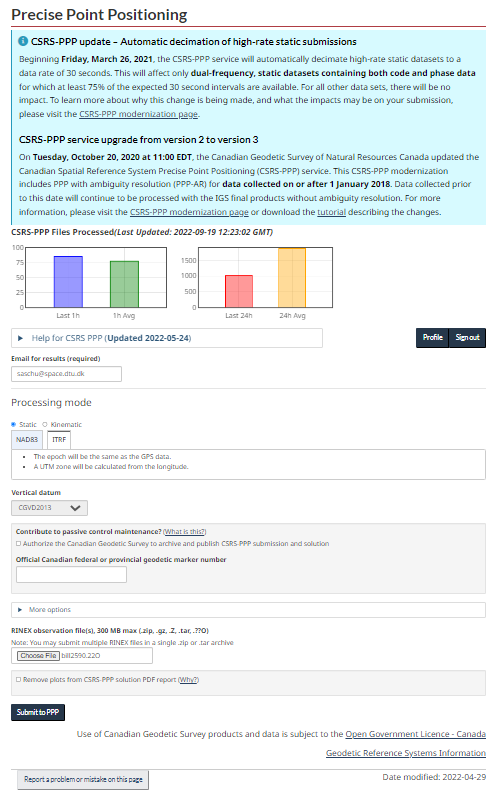


## Observationer
Vi kan nu samle positionerne og spredningerne fra de forsekllige metoder vi har brugt intil nu.

TruePos : Jeres sande værdi for jeres givne fikspunkt

kodePos : Jeres kode løsning ved brug af jeres håndholdte GPS modtager ovenpå punktet

NRCAN : PPP løsning fra statisk observation ved brug af NRCAN <br>
NRCAN giver jer et koordinat i UTM zone 22 samt i geodætiske koordinater. For at lave en syntetisk baselinje, skal disse omregnes til kartesiske koordinater.

FasePos : Bruger PPP løsning fra NRCAN for jeres fikspunkt og referencestationen SISI til at lave en baselinje.

Indsæt PPP løsningerne i kartesiske koordinater de rigtige steder i scriptet under for at beregne jeres Fase position.

In [2]:
FixPoint_nrcanPos_UTM = array([382715.573, 7427154.928, 61.813])    # <-- indsæt dine værdier fra NRCAN i UTM zone 22 her (ITRF2020, epoke t_obs)
FixPoint_true_UTM = array([382716.145, 7427154.542, 61.838])        # <-- indsæt værdier for dit punkt fra fikspunktsbeskrivelsen her i UTM zone 22 (GR96)
PPP_sisi_station_UTM = array([383171.503, 7426564.603, 112.936])    # <-- indsæt dine værdier for UTM zone 22 her (NRCAN PPP for SISI, ITRF2020, epoke t_obs)

kodePos = array([382715.794, 7427153.100, 27.800])                  # <-- indsæt dine værdier her (gennemsnitlig kode position, UTM zone 22)

t_obs = 2026.71                                                     # observationsepoke for jeres fikspunkt-fil (2026-09-18, doy 261)

# Reference for SISI: uafhængig PPP-løsning fra en anden dag (doy 200)
SISI_lat  = 66.93430655
SISI_lon  = -53.67286622
SISI_h    = 112.928
t_obs_SISI = 2026.55                                                 # 2026-07-17, doy 200

Vi har dog det problem at vi skal bruge positionerne i kartesiske koordinater.. derfor bliver vi altså nødt til at transformere koordinaterne. <br>
Brug det i har lært fra grupperegning 2, til at løse vores lille problem. Prøv rigtig gerne selv om i kan finde den rigtige pipeline før i spørger om hjælp :)

In [10]:
pipeline = "+ellps=GRS80 +proj=pipeline +step +proj=utm +zone=22 +inv +step +proj=cart"
transform_object = Transformer.from_pipeline(pipeline)

FixPoint_nrcanPos = transform_object.transform(*FixPoint_nrcanPos_UTM)      # nrcan position
PPP_sisi = transform_object.transform(*PPP_sisi_station_UTM)                # Sisimiut stationen position
FixPoint_true = transform_object.transform(*FixPoint_true_UTM)              # fikspunkt position

to_utm = Transformer.from_pipeline("+ellps=GRS80 +proj=pipeline +step +proj=cart +inv +step +proj=utm +zone=22")

print(f'PPP position for jeres statiske måling [x,y,z]: {FixPoint_nrcanPos}')
print(f'PPP position for Sisimiut stationen [x,y,z]: {PPP_sisi}')
print(f'Den sande position for jeres fikspunkt [x,y,z]: {FixPoint_true}')

PPP position for jeres statiske måling [x,y,z]: (1483843.7862060214, -2018816.7298643622, 5845827.183644092)
PPP position for Sisimiut stationen [x,y,z]: (1484554.0088935243, -2018970.7321735304, 5845650.802974219)
Den sande position for jeres fikspunkt [x,y,z]: (1483844.4627479813, -2018816.6570692775, 5845827.065209505)


Nu skriver vi alle vores observationer op.

Find jeres gennemsnitlige kode position frem og indskriv den i kodePos <br>
Vi vil gerne sammenligne i UTM zone 22, da det er nemmere at forstå positionen i forhold til et [x, y, z] koordinat, så indskriv nedenstående koordinater i UTM zone 22

In [4]:
truePos  = FixPoint_true_UTM
nrcanPos = FixPoint_nrcanPos_UTM

## Reference frame: ITRF2020 vs. GR96

NRCAN giver positioner i **ITRF2020** til observationstidspunktet. Fikspunktsbeskrivelsen er i **GR96**, som er fastlåst til den grønlandske plade (ITRF94, epoke 1996.62). Grønland bevæger sig ca. 2 cm/år, så over ~30 år giver det en forskel på ca. 0.7 m mellem de to rammer.

Vi transformerer derfor PPP-positionerne fra ITRF2020 til GR96 med den officielle tidsafhængige transformation (EPSG:10960, *ITRF2020 to GR96(2021)*).

In [ ]:
# ITRF2020 <-> GR96(2021), tidsafhængig transformation (EPSG:10960). Kræver en nyere PROJ.
T  = Transformer.from_crs("EPSG:9988", "EPSG:10957", always_xy=True)    # ITRF2020 -> GR96(2021)
Ti = Transformer.from_crs("EPSG:10957", "EPSG:9988", always_xy=True)    # GR96(2021) -> ITRF2020
to_gr = lambda xyz, t: np.array(T.transform(*xyz, t))[:3]               # ITRF2020 @ t -> GR96
to_itrf = lambda xyz, t: np.array(Ti.transform(*xyz, t))[:3]            # GR96 -> ITRF2020 @ t

nrcan_GR96_xyz    = to_gr(FixPoint_nrcanPos, t_obs)
PPP_sisi_GR96_xyz = to_gr(PPP_sisi, t_obs)
nrcan_GR96 = array(to_utm.transform(*nrcan_GR96_xyz))

print("NRCAN, målt (ITRF2020) :", nrcanPos)
print("NRCAN, projekteret GR96:", nrcan_GR96)
print("Afvigelse fra sand position [E,N,U]:", nrcan_GR96 - truePos)

NRCAN, målt (ITRF2020) : [3.82715573e+05 7.42715493e+06 6.18130000e+01]
NRCAN, projekteret GR96: [3.82716143e+05 7.42715457e+06 6.17299715e+01]
Afvigelse fra sand position [E,N,U]: [-0.00208766  0.03113805 -0.10802847]


## SISI-reference: uafhængig PPP-løsning (doy 200)

Som reference for SISI bruger vi en PPP-løsning fra en anden dag (doy 200), transformeret til GR96 til sin egen epoke. For at sikre os at det virker, sammenligner vi den med to andre uafhængige estimater af SISI's GR96-position: RINEX-headerens a priori position, og PPP-løsningen fra selve fikspunkt-filen (doy 261). Er de enige, kan vi bruge doy 200-løsningen som `SISI_true`.

In [12]:
llh_to_ecef = Transformer.from_pipeline("+ellps=GRS80 +proj=pipeline +step +proj=latlong +step +proj=cart")

# Til sammenligning: RINEX-header a priori (GR96, ingen epoke nødvendig) og doy 261 PPP -> GR96
SISI_hdr_lat = 66 + 56/60 + 3.49295/3600
SISI_hdr_lon = -(53 + 40/60 + 22.27000/3600)
SISI_hdr_h   = 112.840
SISI_hdr_xyz      = np.array(llh_to_ecef.transform(SISI_hdr_lon, SISI_hdr_lat, SISI_hdr_h))
SISI_doy261_gr96  = to_gr(PPP_sisi, t_obs)

# Vores nye reference: doy 200 PPP -> GR96 til sin egen epoke
SISI_true = np.array(llh_to_ecef.transform(SISI_lon, SISI_lat, SISI_h))
SISI_true_gr96 = to_gr(SISI_true, t_obs_SISI)

print(f"{'Kilde':28s}{'Easting':>14s}{'Northing':>14s}{'Højde':>10s}")
for navn, xyz in [("Header a priori", SISI_hdr_xyz),
                   ("PPP doy 261 -> GR96", SISI_doy261_gr96),
                   ("PPP doy 200 -> GR96 (SISI_true)", SISI_true_gr96)]:
    e, n, h = to_utm.transform(*xyz)
    print(f"{navn:34s}{e:10.3f}{n:14.3f}{h:10.3f}")

Kilde                              Easting      Northing     Højde
Header a priori                   383172.081   7426564.246   112.840
PPP doy 261 -> GR96               383172.073   7426564.248   112.853
PPP doy 200 -> GR96 (SISI_true)   383172.075   7426564.247   112.845


## Syntetisk baselinje og Fase position

`SISI_true` (doy 200, GR96) bringes til fikspunktets epoke (`t_obs`) og lægges sammen med den syntetiske baselinje.

In [13]:
Baselinje = np.array(FixPoint_nrcanPos) - np.array(PPP_sisi)      # ITRF2020 @ t_obs

SISI_itrf_obs = to_itrf(SISI_true_gr96, t_obs)                    # SISI_true -> ITRF2020 @ fikspunktets epoke
FasePos_itrf  = SISI_itrf_obs + Baselinje
FasePos_GR96  = array(to_utm.transform(*to_gr(FasePos_itrf, t_obs)))

print("Fase position (GR96, UTM 22):", FasePos_GR96)
print("Afvigelse fra sand position [E,N,U]:", FasePos_GR96 - truePos)
print("Horisontal afvigelse [m]:", linalg.norm((FasePos_GR96 - truePos)[:2]))

Fase position (GR96, UTM 22): [3.82716145e+05 7.42715457e+06 6.17219760e+01]
Afvigelse fra sand position [E,N,U]: [-4.82009491e-05  3.04820389e-02 -1.16023979e-01]
Horisontal afvigelse [m]: 0.03048207696537289


## Resultater

Forskel til den "sande" position i UTM zone 22 (E, N, U og længde af horisontal/3D-afvigelse).

In [ ]:
resultater = {
    "Kode (håndholdt)": kodePos,
    "NRCAN (ITRF2020)": nrcanPos,
    "NRCAN GR96": nrcan_GR96,
    "Fase GR96": FasePos_GR96,
}
print(f"{'Metode':22s}{'dE [m]':>10s}{'dN [m]':>10s}{'dU [m]':>10s}{'2D [m]':>10s}{'3D [m]':>10s}")
for navn, p in resultater.items():
    d = p - truePos
    print(f"{navn:22s}{d[0]:10.3f}{d[1]:10.3f}{d[2]:10.3f}{linalg.norm(d[:2]):10.3f}{linalg.norm(d):10.3f}")

Metode                    dE [m]    dN [m]    dU [m]    2D [m]    3D [m]
Kode (håndholdt)          -0.351    -1.442   -34.038     1.484    34.070
NRCAN (ITRF2020)          -0.572     0.386    -0.025     0.690     0.691
NRCAN GR96                -0.002     0.031    -0.108     0.031     0.112
Fase GR96                 -0.000     0.030    -0.116     0.030     0.120


## Visuel vurdering af observationer

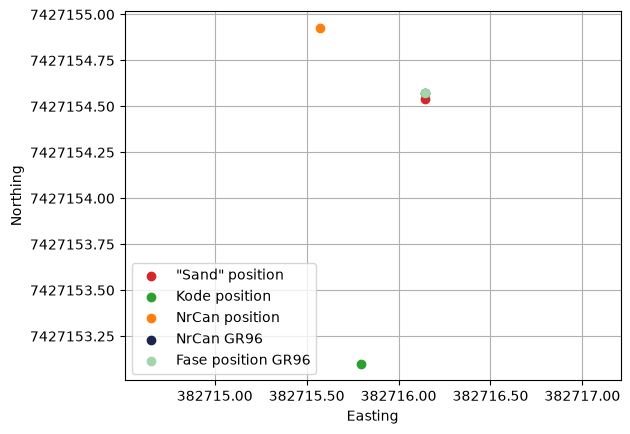

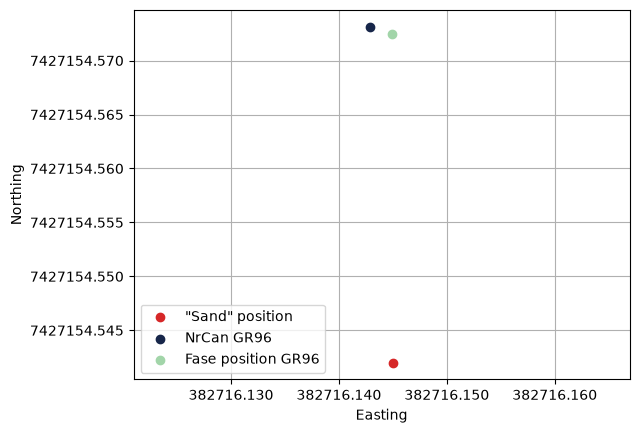

In [17]:
def plot_positions(punkter, decimals=2):
    plt.figure()
    for label, (p, color) in punkter.items():
        plt.scatter(p[0], p[1], color=color, label=label)
    plt.xlabel('Easting')
    plt.ylabel('Northing')
    plt.legend(loc='lower left')
    plt.grid(True)
    plt.axis('equal')
    plt.gca().xaxis.set_major_formatter(plt.FormatStrFormatter(f'%.{decimals}f'))
    plt.gca().yaxis.set_major_formatter(plt.FormatStrFormatter(f'%.{decimals}f'))
    plt.show()

plot_positions({
    '"Sand" position':  (truePos,       'tab:red'),
    'Kode position':    (kodePos,       'tab:green'),
    'NrCan position':   (nrcanPos,      'tab:orange'),
    'NrCan GR96':       (nrcan_GR96,    '#17264a'),
    'Fase position GR96': (FasePos_GR96,'#a2d5a9'),
})

plot_positions({
    '"Sand" position':    (truePos,      'tab:red'),
    'NrCan GR96':         (nrcan_GR96,   '#17264a'),
    'Fase position GR96': (FasePos_GR96, '#a2d5a9'),
}, decimals=3)

# Kommentarer til resultaterne
Her skal I bruge 1/2 - 1 side på at beskrive jeres resultater. Brug de figurer og beregninger i har lavet!

f.eks:
  - Hvor tæt kom de forskellige metoder på den faktiske koordinat?
  - Hvor stor er spredningen ved brug af de forskellige metoder?
  - Stemmer resultaterne overens med det forventede i forhold til fejlteori og GNSS teori?
  - Skiller nogle metoder sig ud?